## Practice 2: AI-based Short-term Load forecasting using LSTM

Instructor: Mojtaba Mohammadikarachi


In [147]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from pandas.plotting import register_matplotlib_converters
from keras.models import Sequential
from keras.layers import LSTM
import warnings
from sklearn.preprocessing import RobustScaler
from datetime import datetime
import hashlib
import os


warnings.filterwarnings(action='ignore')
%matplotlib inline
%config InlineBackend.figure_format='retina'

register_matplotlib_converters()
sns.set_theme(style='whitegrid', context='talk')
sns.set_palette(['#0F766E', '#EA580C', '#2563EB', '#9333EA', '#DC2626'])

plt.rcParams['figure.figsize'] = (16, 7)
plt.rcParams['axes.facecolor'] = '#FCFCFD'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#D1D5DB'
plt.rcParams['grid.color'] = '#D1D5DB'
plt.rcParams['grid.alpha'] = 0.35
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelcolor'] = '#111827'
plt.rcParams['xtick.color'] = '#374151'
plt.rcParams['ytick.color'] = '#374151'
plt.rcParams['font.size'] = 12

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# model patameters
Dropout_rate = 0.3
batch_size = 32
time_steps = 14
no_epochs = 10
test_ratio = 0.2

- reading the data from the csv file


In [148]:

df = pd.read_csv(
  "https://raw.githubusercontent.com/mojmhmdi/Time-series-electrical-load-forecasting-using-LSTM/refs/heads/master/malaysia_all_data_for_paper.csv", 
  parse_dates=['date'], 
  index_col="date"
)

- plotting the active power values


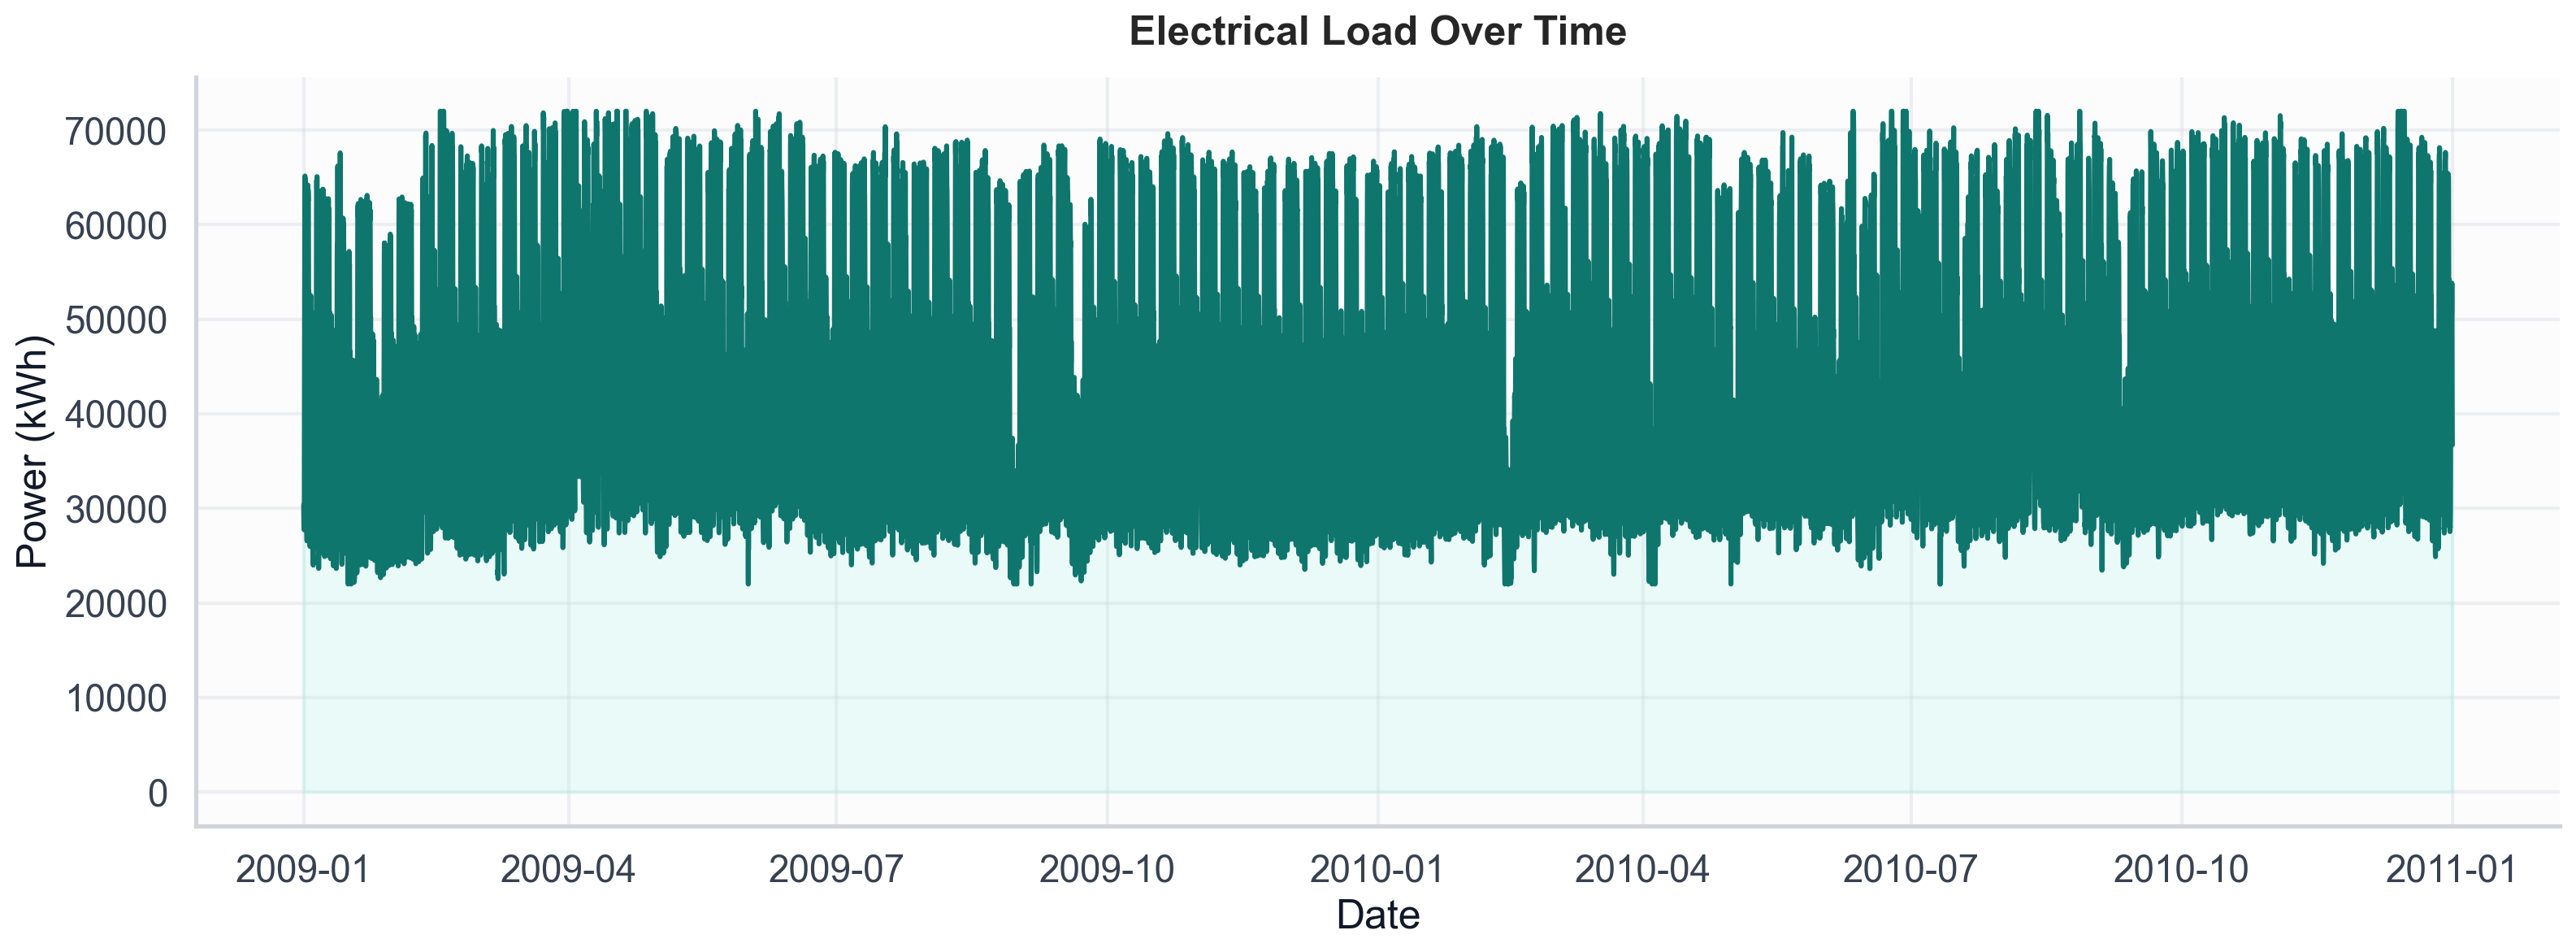

In [161]:
# this section generates the data indexes
df['hour'] = df.index.hour
df['day_of_month'] = df.index.day
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x=df.index, y='power', data=df, ax=ax, color='#0F766E', linewidth=2.2)
ax.set_title('Electrical Load Over Time', pad=14)
ax.set_xlabel('Date')
ax.set_ylabel('Power (kWh)')
ax.fill_between(df.index, df['power'].to_numpy(), color='#99F6E4', alpha=0.18)
sns.despine()
plt.tight_layout();

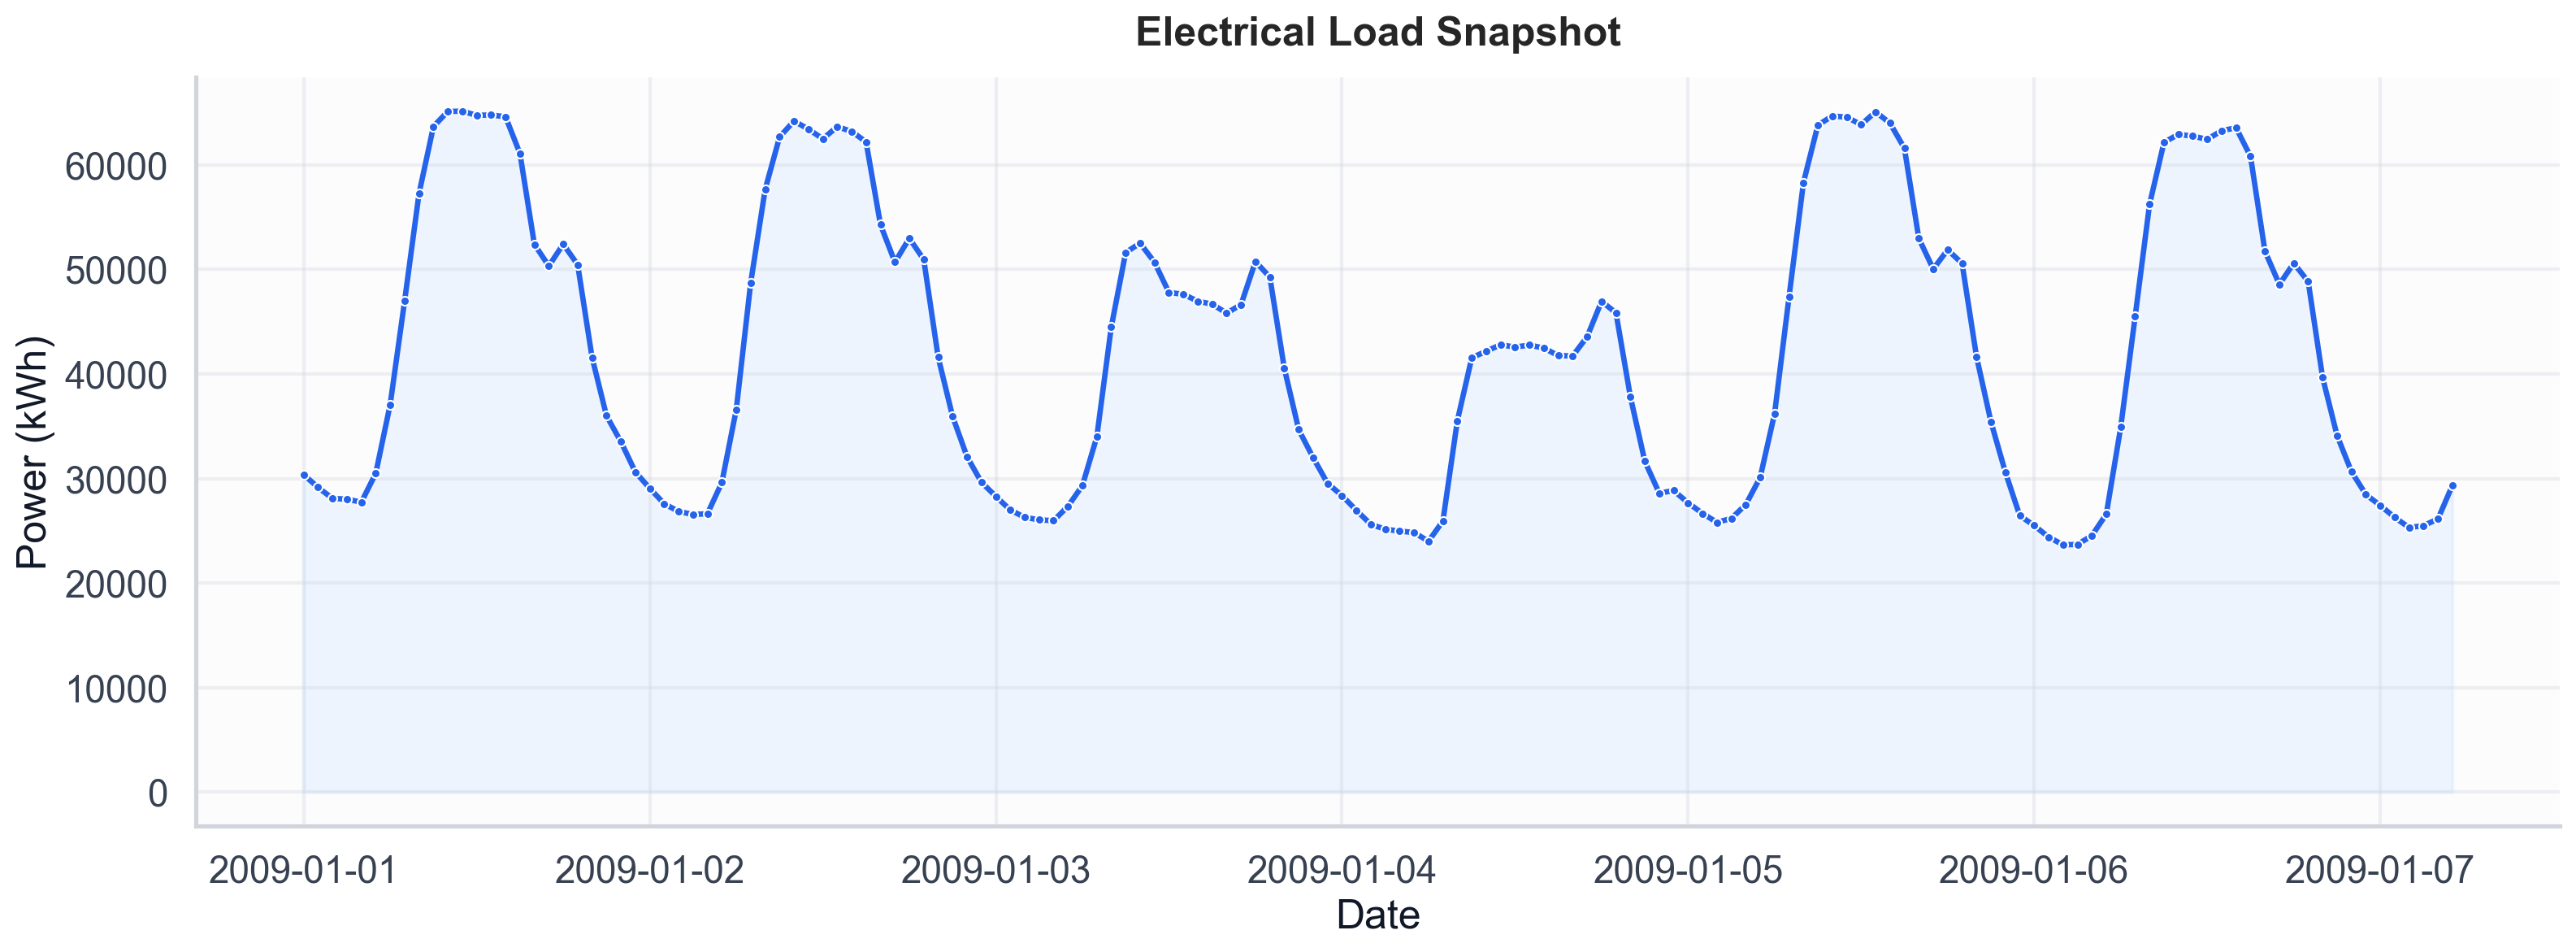

In [166]:
fig, ax = plt.subplots(figsize=(16, 6))
subset = df.iloc[:150]
sns.lineplot(x=subset.index, y='power', data=subset, ax=ax, color='#2563EB', linewidth=2.4, marker='o', markersize=4)
ax.set_title('Electrical Load Snapshot', pad=14)
ax.set_xlabel('Date')
ax.set_ylabel('Power (kWh)')
ax.fill_between(subset.index, subset['power'].to_numpy(), color='#BFDBFE', alpha=0.22)
sns.despine()
plt.tight_layout();

- Some data visualization for understanding the data


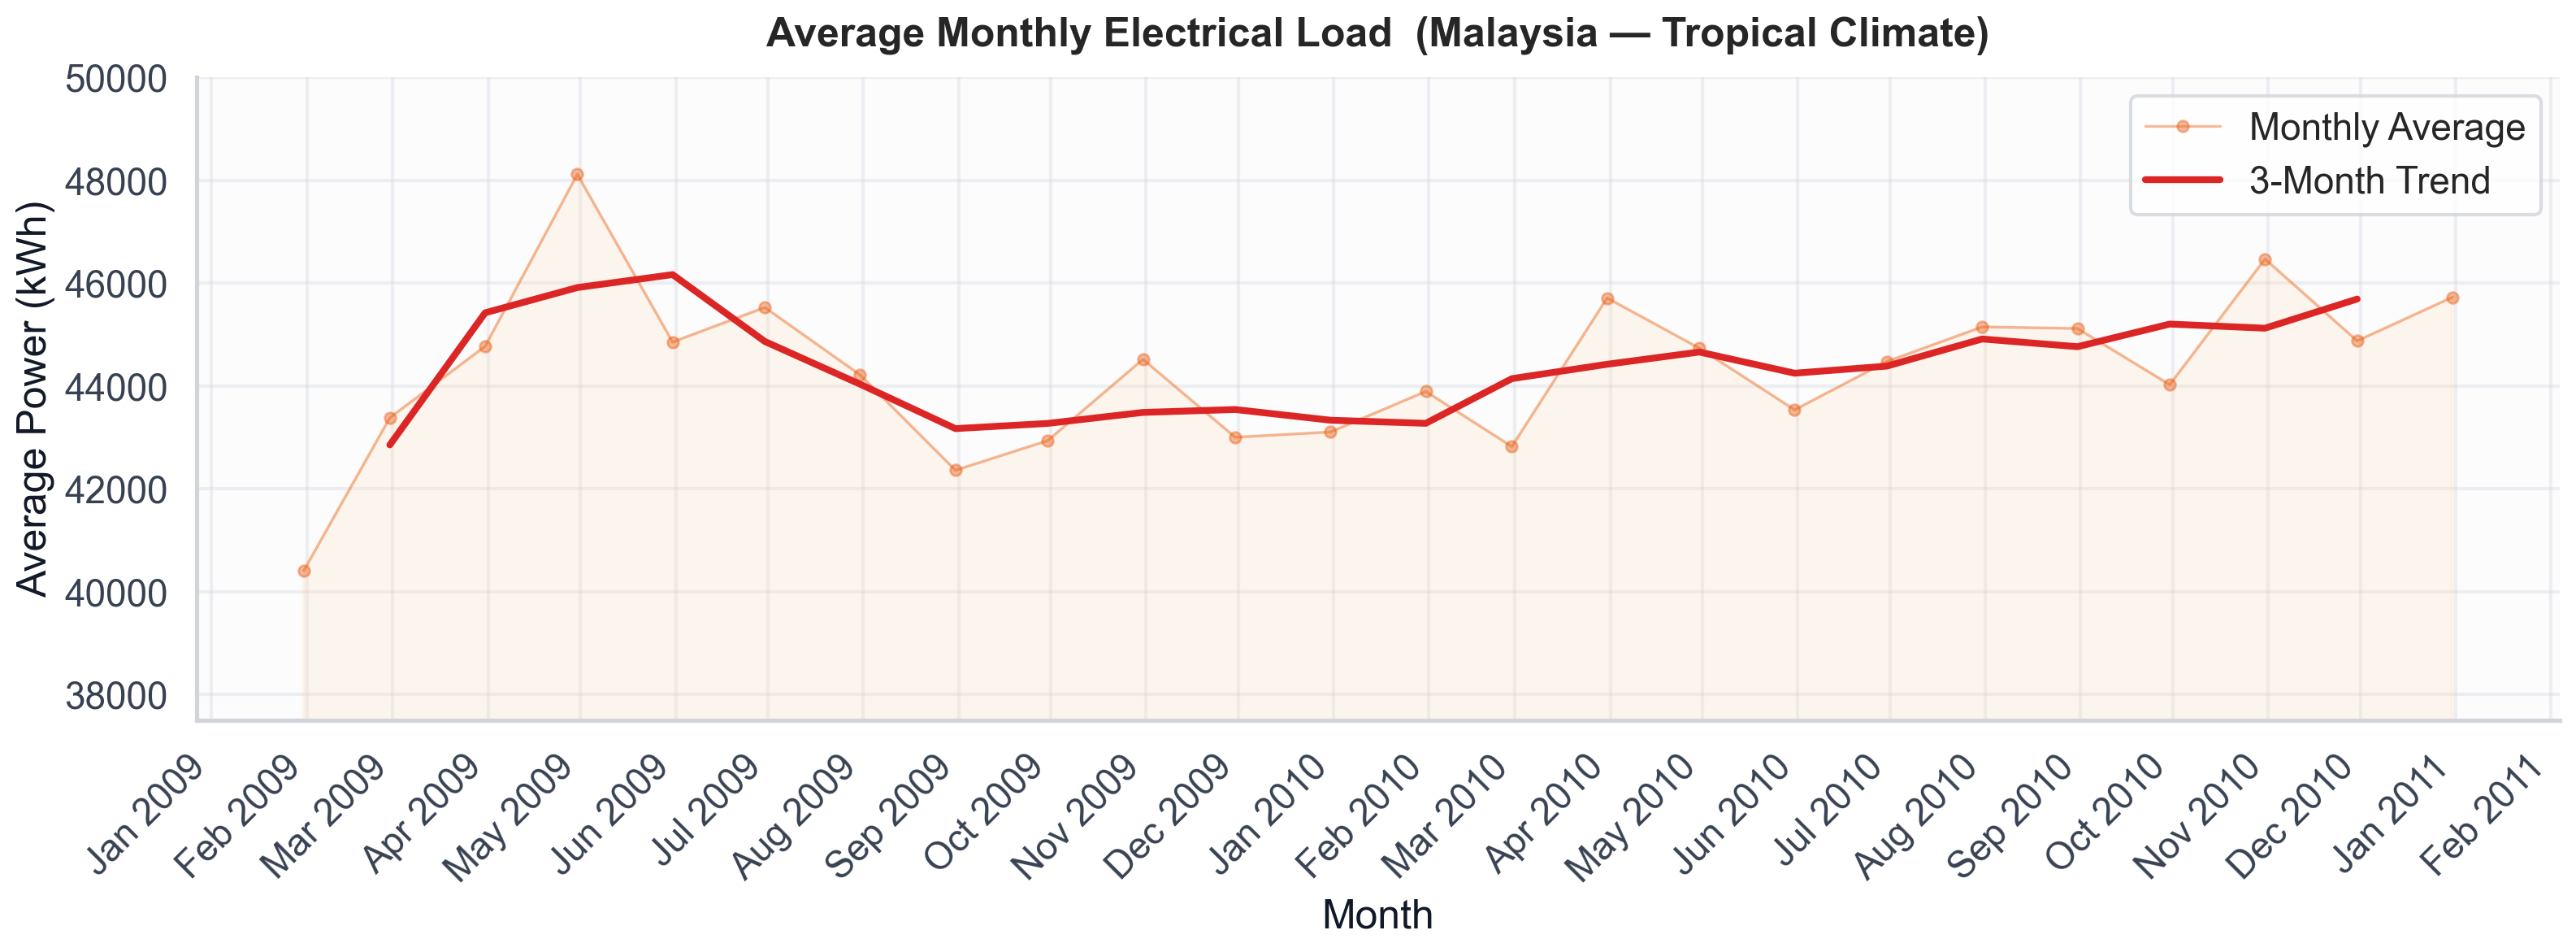

In [167]:
import matplotlib.dates as mdates

df_by_month = df.resample('M').mean()
# 3-month rolling average to reveal the underlying trend
df_trend = df_by_month['power'].rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 6))

# Raw monthly data — light/faded
ax.plot(df_by_month.index, df_by_month['power'],
        color='#EA580C', linewidth=1.2, alpha=0.4,
        marker='o', markersize=5, label='Monthly Average')

# Smooth trend line — bold
ax.plot(df_by_month.index, df_trend,
        color='#DC2626', linewidth=3, label='3-Month Trend', zorder=5)

ax.fill_between(df_by_month.index, df_by_month['power'].to_numpy(), color='#FED7AA', alpha=0.18)
ax.set_title('Average Monthly Electrical Load  (Malaysia — Tropical Climate)', pad=14)
ax.set_xlabel('Month')
ax.set_ylabel('Average Power (kWh)')
ax.set_ylim(37500, 50000)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(frameon=True, facecolor='white', edgecolor='#D1D5DB')
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout();

- plotting the data considering the average active power values for days of the week and days of month


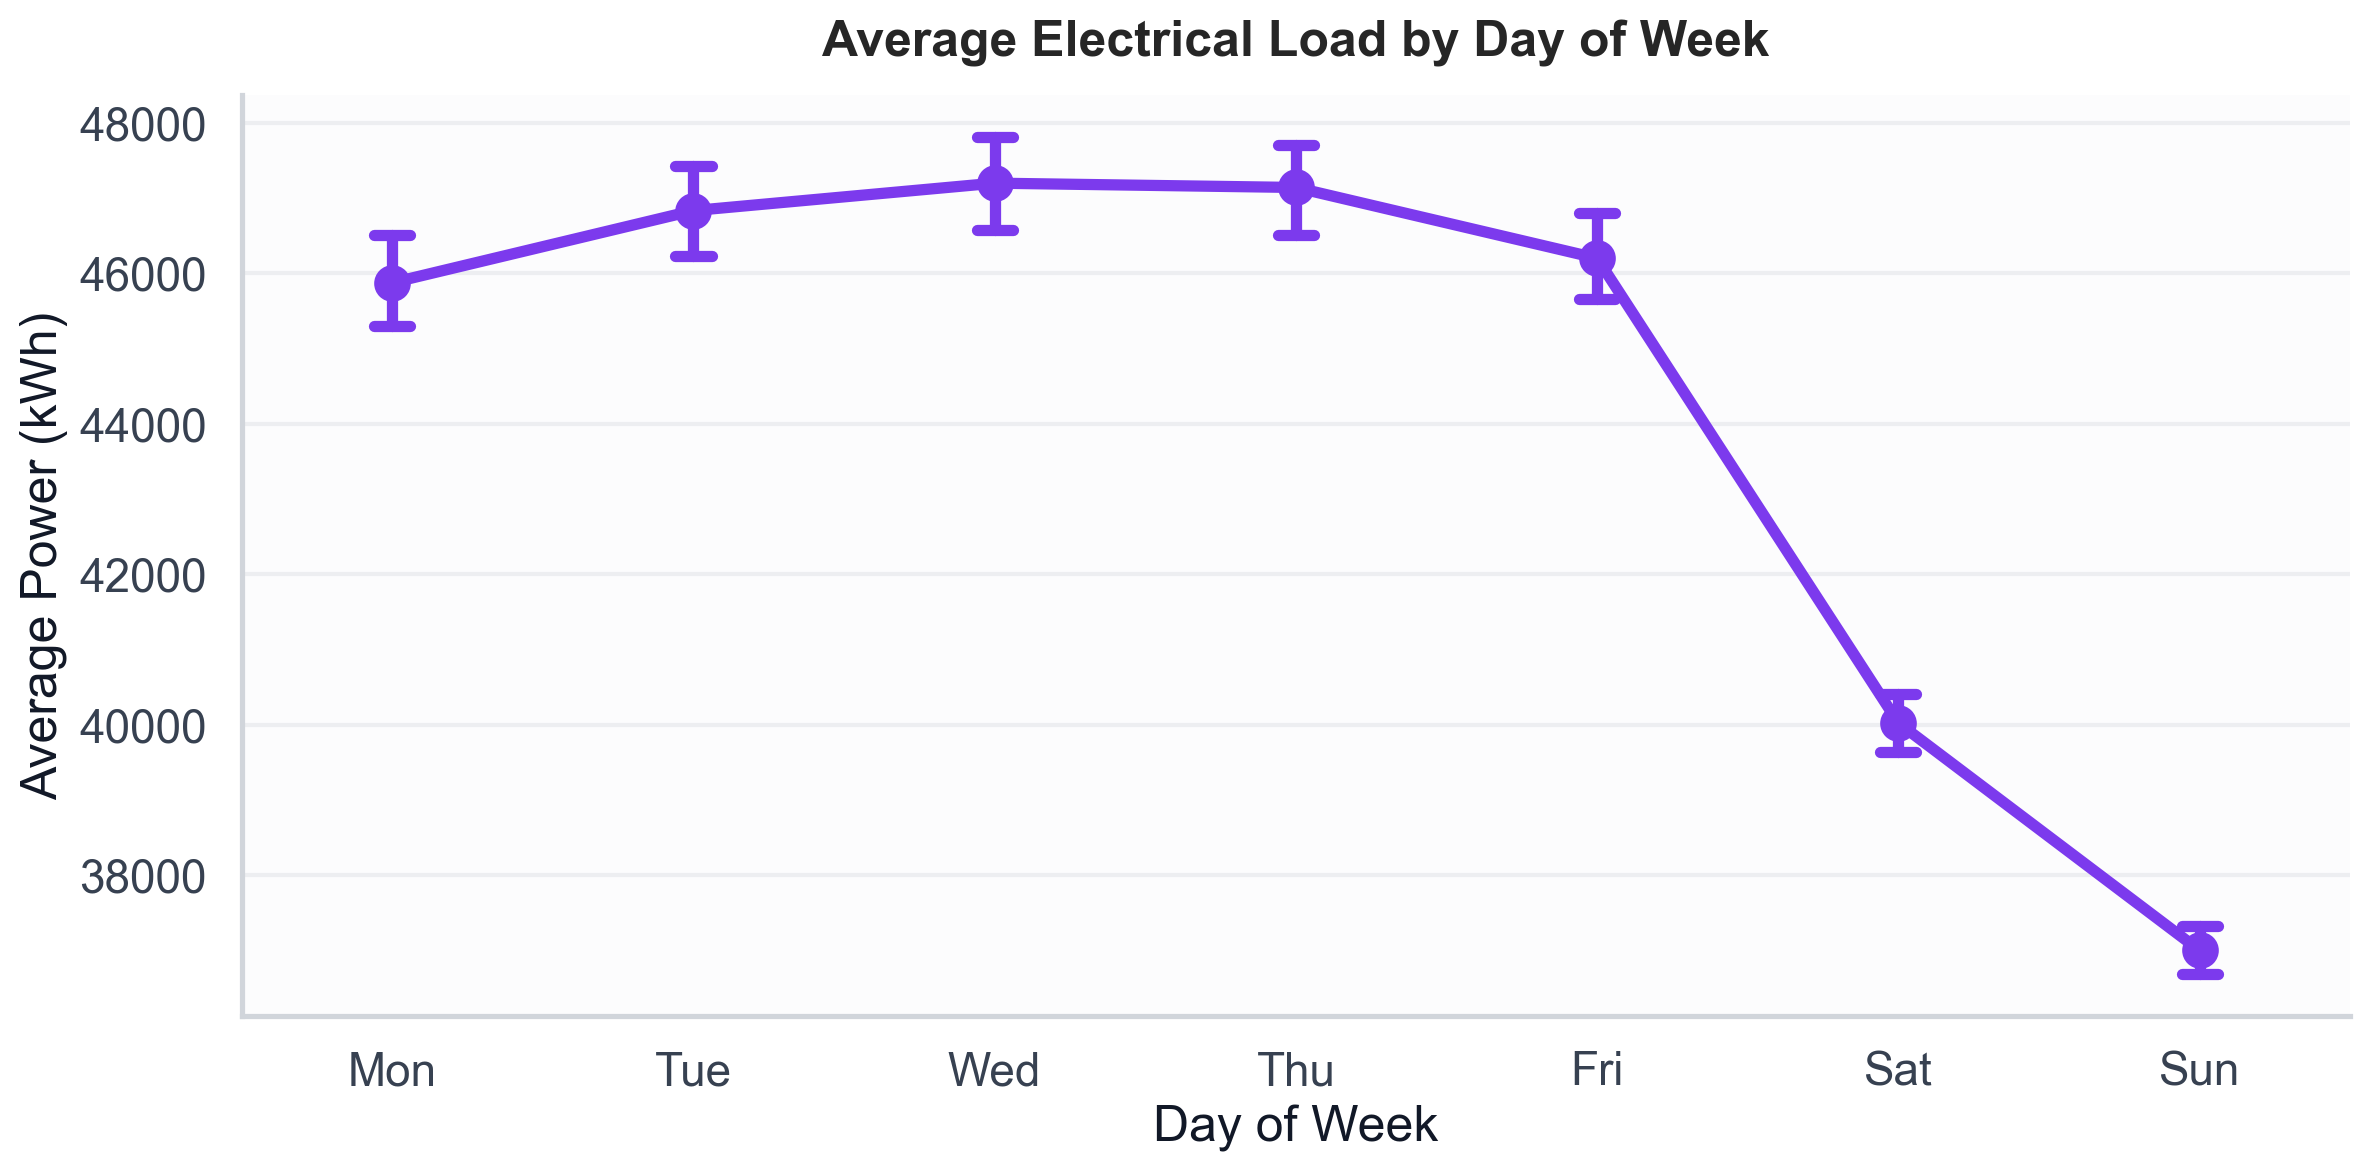

In [153]:
fig, ax1 = plt.subplots(figsize=(12, 6))
weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

sns.pointplot(
    data=df,
    x='day_of_week',
    y='power',
    ax=ax1,
    order=range(7),
    color='#7C3AED',
    errorbar=('ci', 95),
    capsize=0.12,
    linestyles='-'
)
ax1.set_xticks(range(7))
ax1.set_xticklabels(weekday_labels)
ax1.set_title('Average Electrical Load by Day of Week', pad=14)
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Average Power (kWh)')
sns.despine()
plt.tight_layout();

# Preprocessing


In [168]:
train_size = int(len(df) * (1- test_ratio))
test_size = len(df) - train_size
train, test = df.iloc[0:train_size], df.iloc[train_size:]
print(len(train), len(test))


df.drop([ 'day_of_month'], axis=1, inplace=True)
#f_transformer = RobustScaler()
cnt_transformer = RobustScaler()

#f_transformer = f_transformer.fit(train[f_columns].to_numpy())
cnt_transformer = cnt_transformer.fit(train[['power']])

#train.loc[:, f_columns] = f_transformer.transform(train[f_columns].to_numpy())
train['power'] = cnt_transformer.transform(train[['power']])

#test.loc[:, f_columns] = f_transformer.transform(test[f_columns].to_numpy())
test['power'] = cnt_transformer.transform(test[['power']])

# one hour output
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)         
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)


# reshape to [samples, time_steps, n_features]

X_train, y_train = create_dataset(train, train.power, time_steps)
X_test, y_test = create_dataset(test, test.power, time_steps)


14015 3504


# Creating the LSTM model


In [155]:
model = keras.Sequential()
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(LSTM(units=128))

model.add(keras.layers.Dropout(rate=Dropout_rate))
model.add(keras.layers.Dense(units=1,activation="linear"))
keras.backend.set_epsilon(1)
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mape'])


# training the model


Epoch 1/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0122 - mape: 8.3250 - val_loss: 0.0111 - val_mape: 7.9080
Epoch 2/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0083 - mape: 6.9659 - val_loss: 0.0133 - val_mape: 8.9250
Epoch 3/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0078 - mape: 6.6919 - val_loss: 0.0146 - val_mape: 9.6762
Epoch 4/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0074 - mape: 6.5765 - val_loss: 0.0159 - val_mape: 10.2073
Epoch 5/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0068 - mape: 6.2787 - val_loss: 0.0127 - val_mape: 9.2129
Epoch 6/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0065 - mape: 6.1257 - val_loss: 0.0101 - val_mape: 8.0397
Epoch 7/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0058 - mape: 5.7616 - val_loss: 0.0112 - val_mape: 8.7186
Epoch 8/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0056 - mape: 5.6430 - val_loss: 0.0072 - val_mape: 6.6646
Epoch 9/10
394/394 ━━━━━━━━━━━━━━━━━━━━

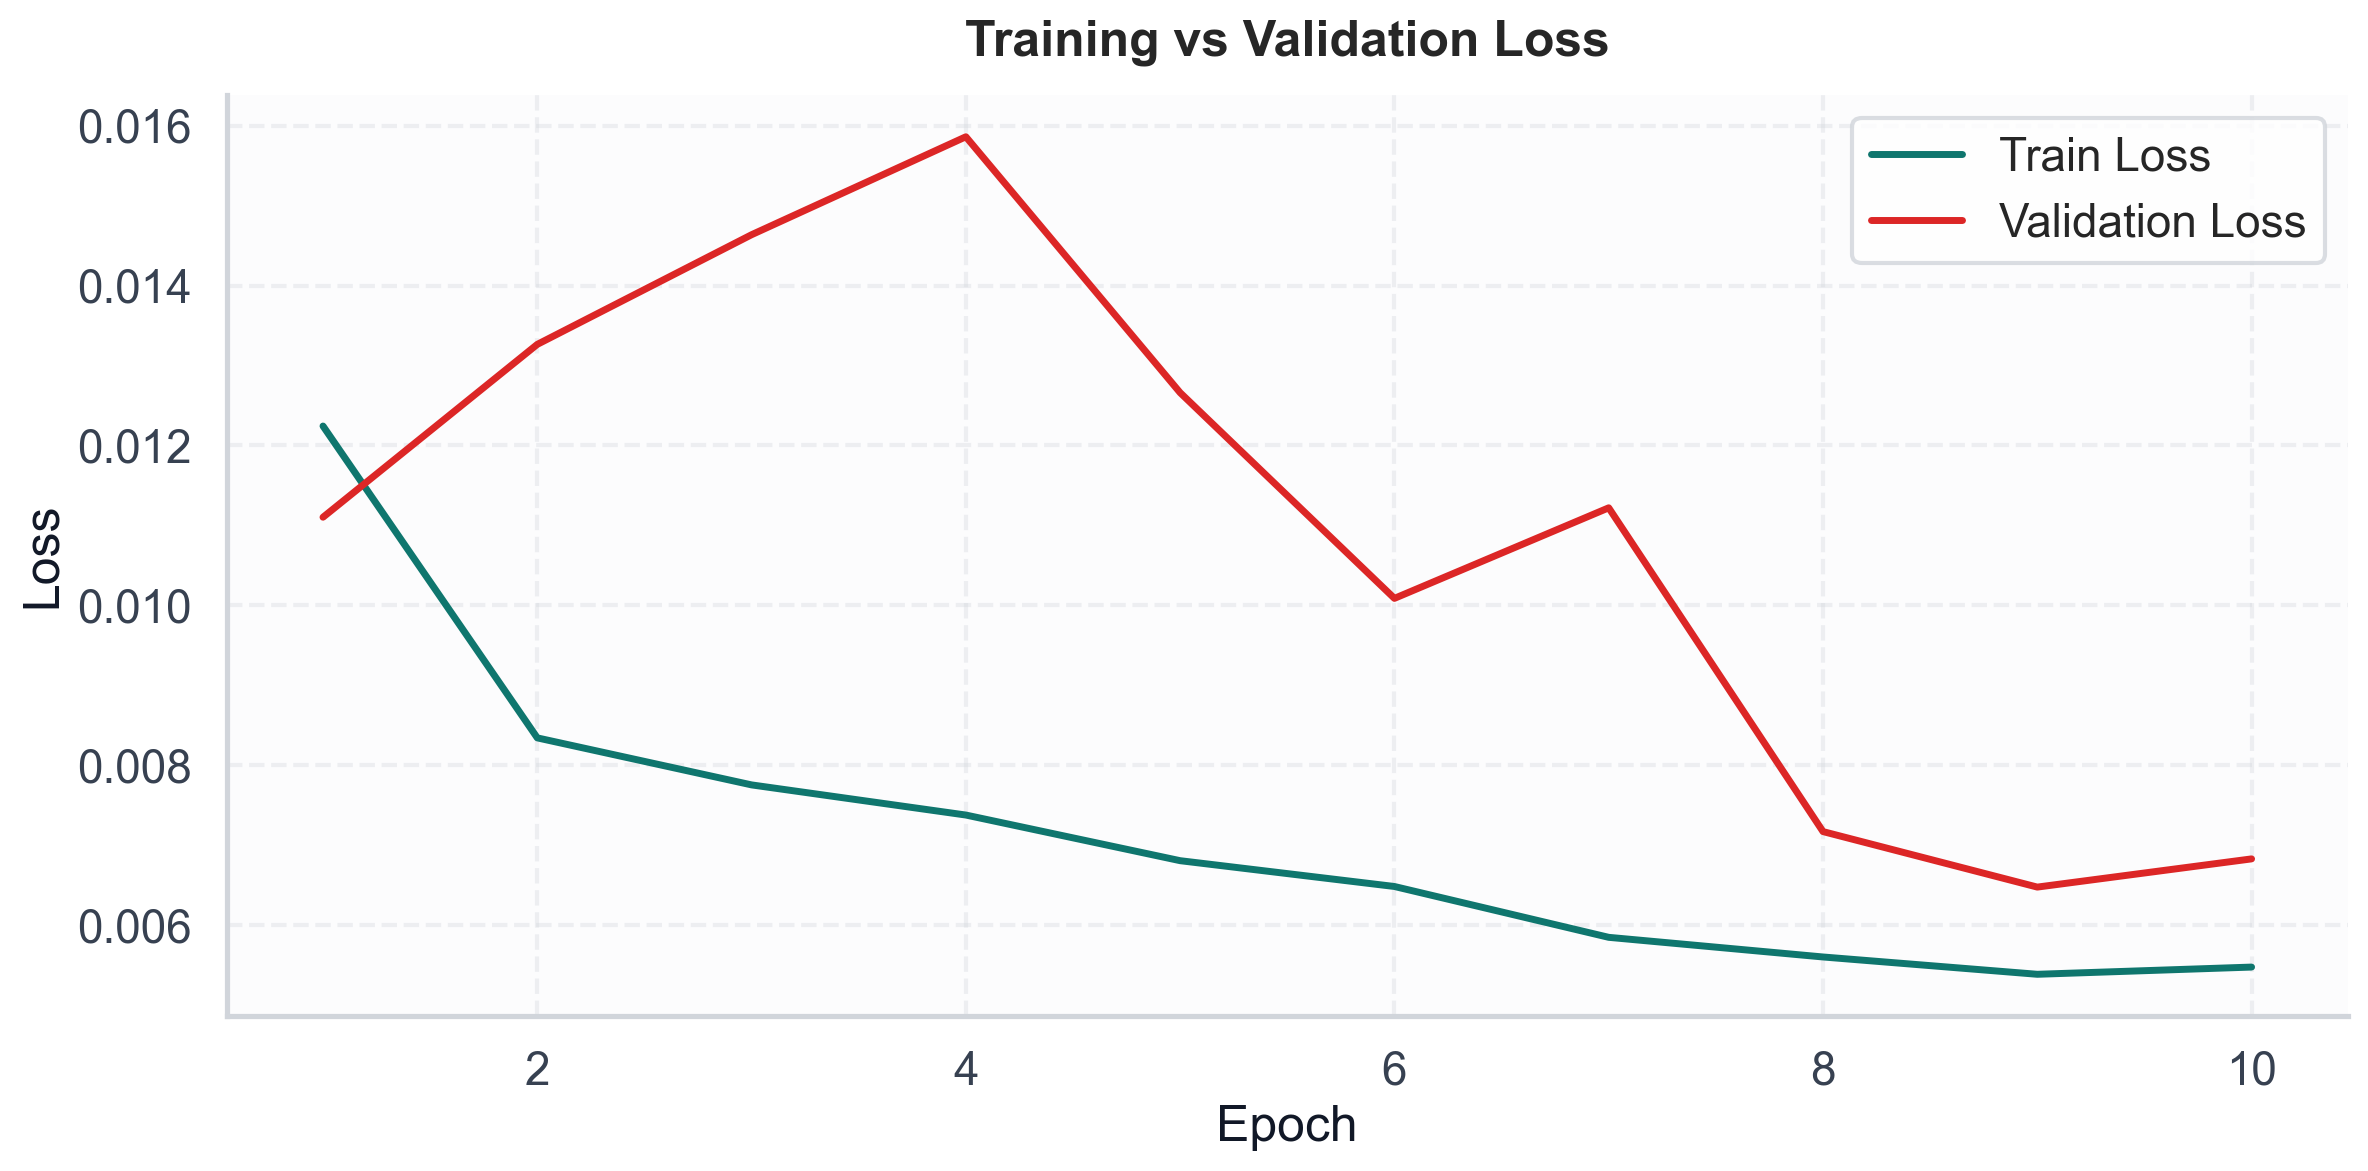

In [169]:
history = model.fit(
    X_train, y_train, 
    epochs=no_epochs, 
    verbose=1,
    batch_size=batch_size, 
    validation_split=0.1,
    shuffle=False
)

fig, ax = plt.subplots(figsize=(12, 6))
epochs = range(1, len(history.history['loss']) + 1)
ax.plot(epochs, history.history['loss'], label='Train Loss', color='#0F766E', linewidth=2.5)
ax.plot(epochs, history.history['val_loss'], label='Validation Loss', color='#DC2626', linewidth=2.5)
ax.set_title('Training vs Validation Loss', pad=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(frameon=True, facecolor='white', edgecolor='#D1D5DB')
ax.grid(True, linestyle='--', alpha=0.35)
sns.despine()
plt.tight_layout();

- predict test data


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


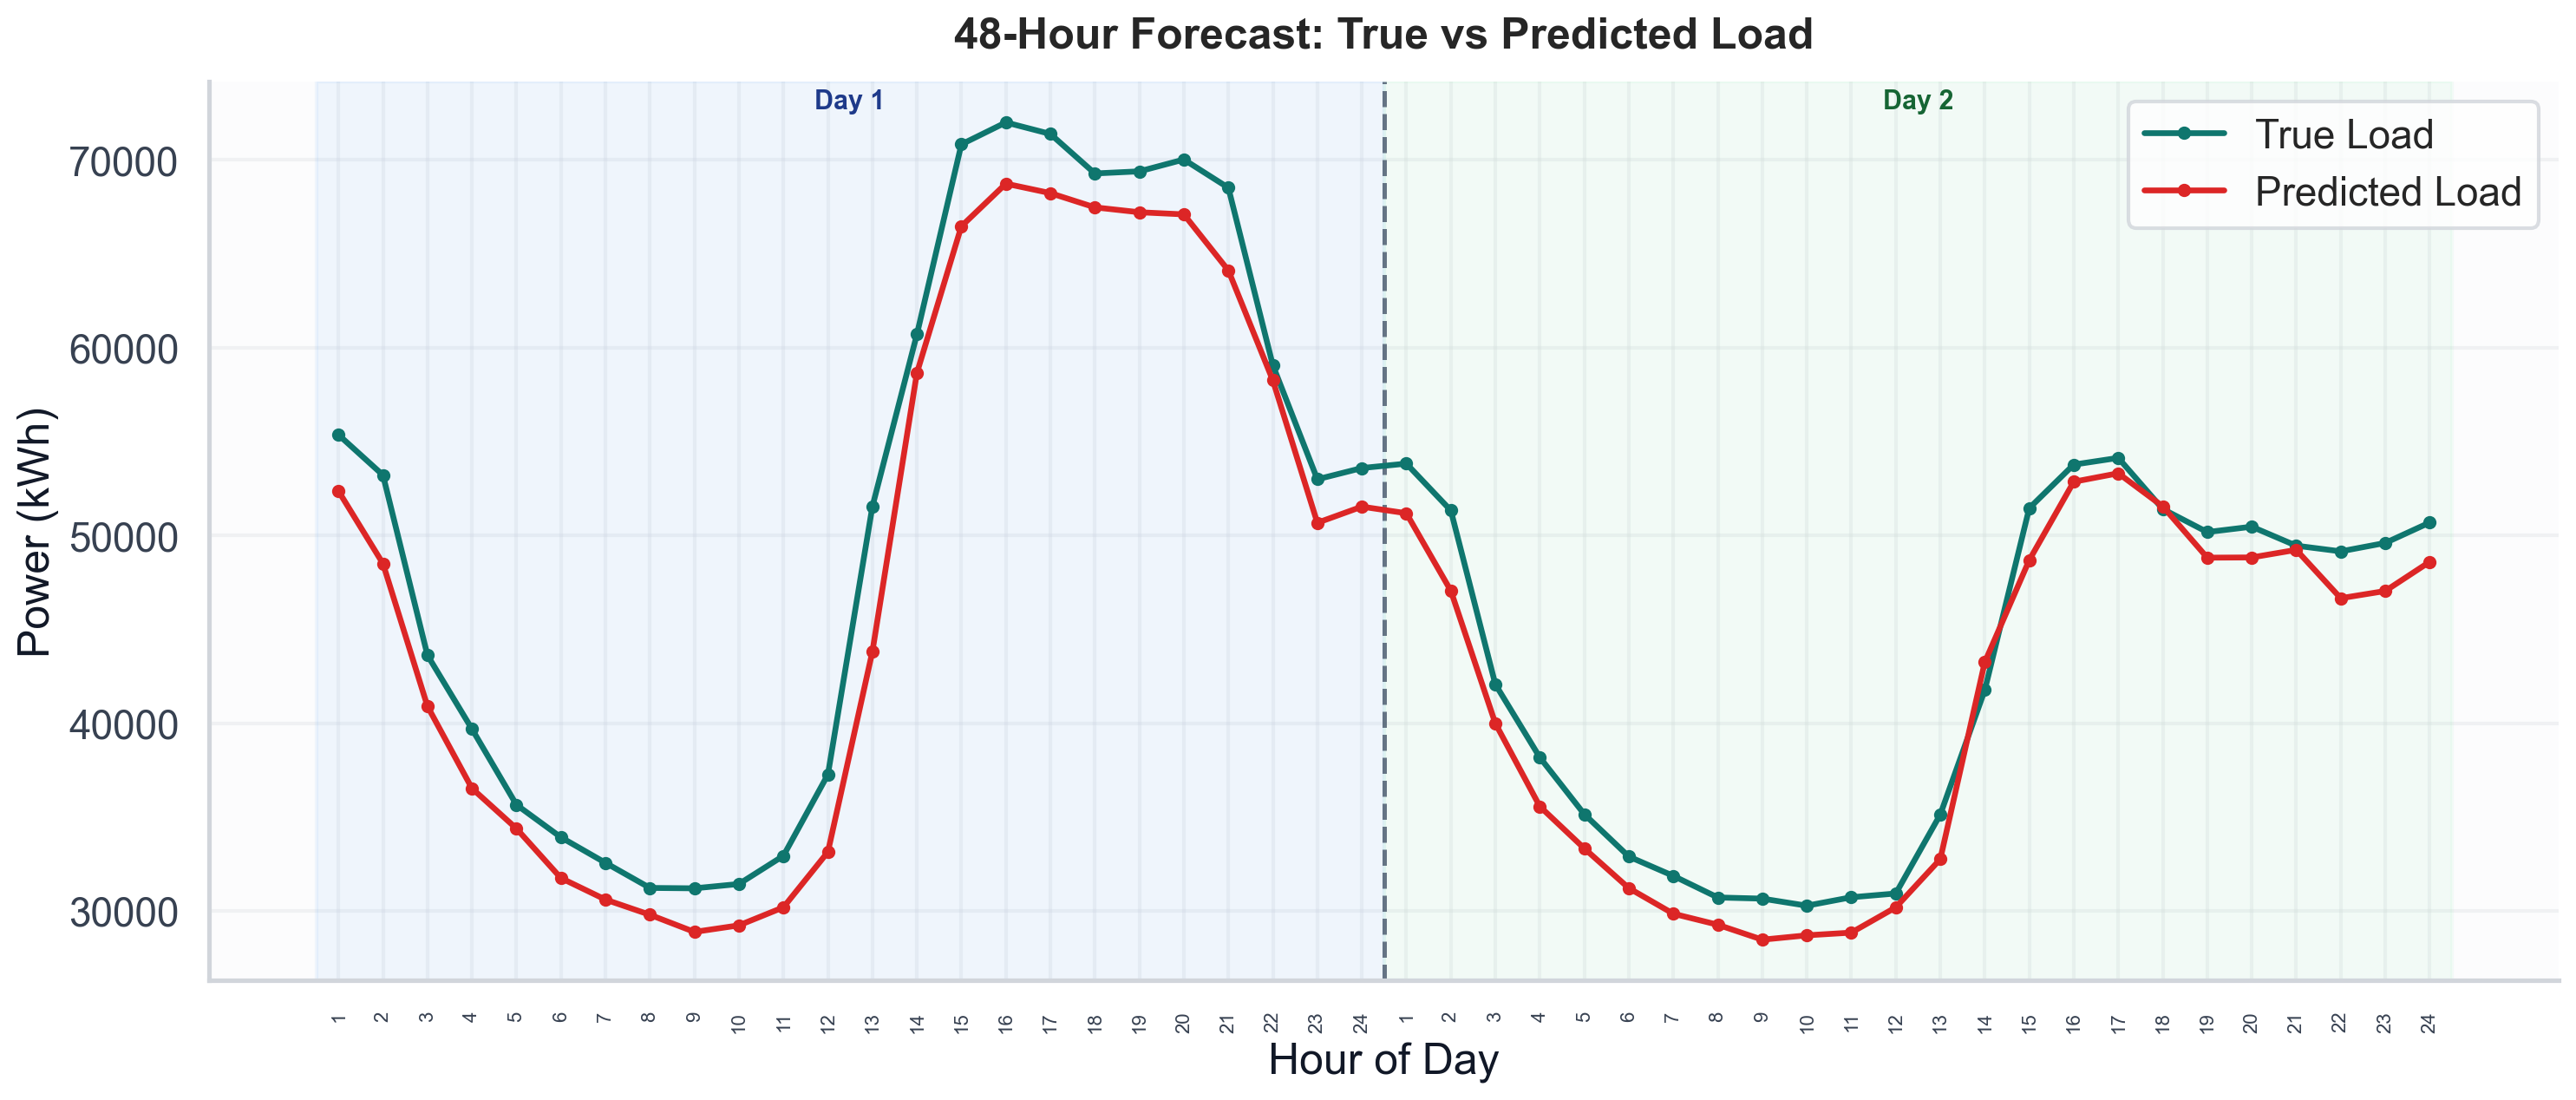

In [170]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)
y_train_inv = cnt_transformer.inverse_transform(y_train.reshape(1, -1))
y_test_inv = cnt_transformer.inverse_transform(y_test.reshape(1, -1))
y_pred_inv = cnt_transformer.inverse_transform(y_pred)
y_pred_train_inv = cnt_transformer.inverse_transform(y_pred_train)

hour_labels = list(range(1, 25)) + list(range(1, 25))
start = 100
x_values = range(1, 49)

fig, ax = plt.subplots(figsize=(15, 6.5))
ax.axvspan(0.5, 24.5, alpha=0.08, color='#60A5FA')
ax.axvspan(24.5, 48.5, alpha=0.08, color='#86EFAC')
ax.axvline(x=24.5, color='#475569', linestyle='--', linewidth=1.8, alpha=0.8)

ax.plot(
    x_values,
    y_test_inv.flatten()[start:start+48],
    marker='o',
    markersize=4.5,
    linewidth=2.4,
    color='#0F766E',
    label='True Load'
)
ax.plot(
    x_values,
    y_pred_inv.flatten()[start:start+48],
    marker='o',
    markersize=4.5,
    linewidth=2.4,
    color='#DC2626',
    label='Predicted Load'
)

upper_y = max(
    y_test_inv.flatten()[start:start+48].max(),
    y_pred_inv.flatten()[start:start+48].max()
)
ax.text(12.5, upper_y * 1.01, 'Day 1', fontsize=11, ha='center', fontweight='bold', color='#1E3A8A')
ax.text(36.5, upper_y * 1.01, 'Day 2', fontsize=11, ha='center', fontweight='bold', color='#166534')

ax.set_xticks(range(1, 49))
ax.set_xticklabels(hour_labels, rotation=90, fontsize=8)
ax.set_title('48-Hour Forecast: True vs Predicted Load', pad=14)
ax.set_ylabel('Power (kWh)')
ax.set_xlabel('Hour of Day')
ax.legend(frameon=True, facecolor='white', edgecolor='#D1D5DB')
ax.grid(True, alpha=0.28)
sns.despine()
plt.tight_layout()
plt.show();

## Submission report


Enter your information here


In [158]:

# Student Information (FILL THIS OUT)
student_name = "Enter your name here"
student_id = "Enter your student ID here"


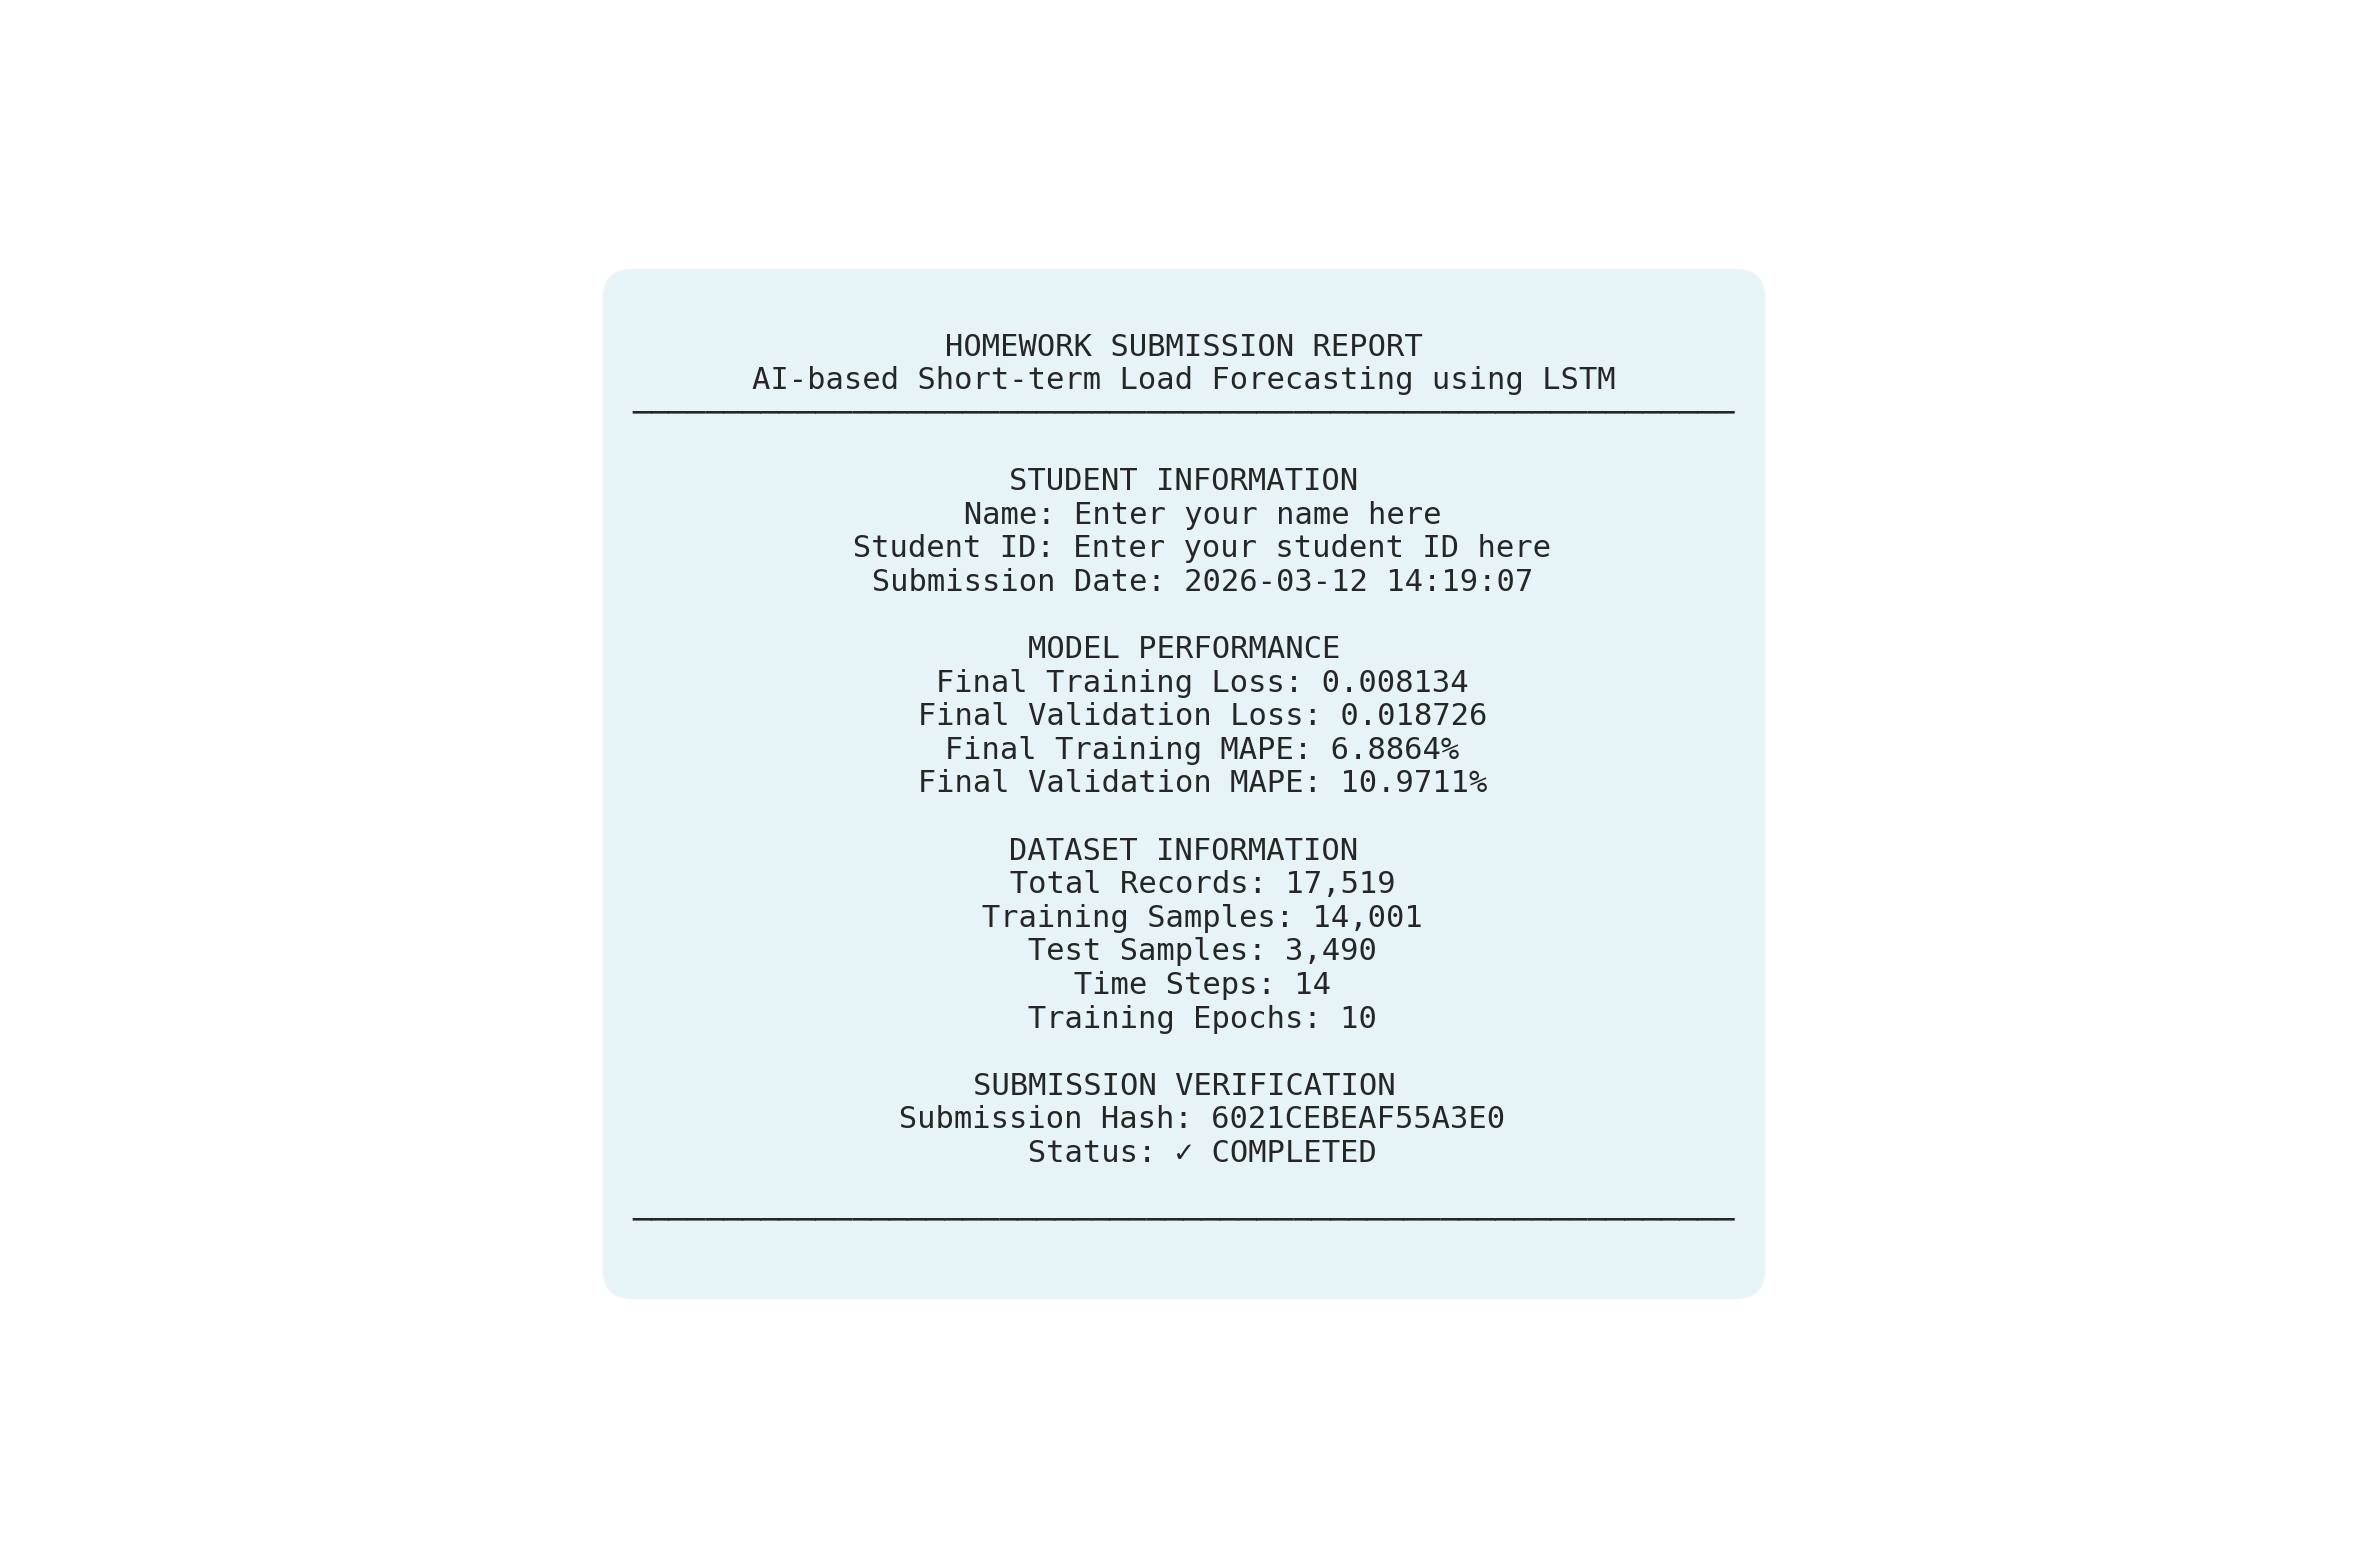


✓ Screenshot this report and submit it as your homework proof!


In [160]:
# CREATE VISUAL SUBMISSION REPORT
submission_time = datetime.now()
fig_report = plt.figure(figsize=(12, 8))
fig_report.patch.set_facecolor('white')
ax_report = fig_report.add_subplot(111)
ax_report.axis('off')

# Calculate metrics
final_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
final_mape = history.history['mape'][-1]
final_val_mape = history.history['val_mape'][-1]

# Submission Hash (proof of execution)
submission_hash = hashlib.md5(
    f"{student_id}{submission_time.isoformat()}{final_val_mape}".encode()
).hexdigest()

# Create visual report
report_text = f"""
HOMEWORK SUBMISSION REPORT
AI-based Short-term Load Forecasting using LSTM
{'─' * 60}

STUDENT INFORMATION
  Name: {student_name}
  Student ID: {student_id}
  Submission Date: {submission_time.strftime('%Y-%m-%d %H:%M:%S')}

MODEL PERFORMANCE
  Final Training Loss: {final_loss:.6f}
  Final Validation Loss: {final_val_loss:.6f}
  Final Training MAPE: {final_mape:.4f}%
  Final Validation MAPE: {final_val_mape:.4f}%

DATASET INFORMATION
  Total Records: {len(df):,}
  Training Samples: {len(X_train):,}
  Test Samples: {len(X_test):,}
  Time Steps: {time_steps}
  Training Epochs: {no_epochs}

SUBMISSION VERIFICATION
  Submission Hash: {submission_hash[:16].upper()}
  Status: ✓ COMPLETED

{'─' * 60}
"""

ax_report.text(0.5, 0.5, report_text, 
              fontsize=11, 
              family='monospace',
              verticalalignment='center',
              horizontalalignment='center',
              bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3, pad=1))

plt.tight_layout()
plt.show()

print("\n✓ Screenshot this report and submit it as your homework proof!")